The kinematics of a two-wheel robot can be given by: 
\begin{equation}
\begin{aligned}
\dot{x} &= v \sin(\theta) \\
\dot{y} &= v \cos(\theta) \\
v &= \frac{r}{2}(\omega_1 + \omega_2) \\
\dot{\theta} &= \frac{r}{L}(\omega_1 + \omega_2) \\
\end{aligned}
\end{equation}

$(x,y)$ are coordinates of the Center of the wheelbase, $\theta$ is the angle of the line perpendicular to the line joining the wheels, relative to the straight line. $\omega_1, \omega_2$ are angular rates of the left and right wheels respectively. 


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [2]:
# system constants
r = 0.025
L = 0.15

In [8]:
def kinematic_model(t, state, omega1, omega2, r, L):
    "first order differential equations for the kinematics"
    "of a two wheel drive robot"
    x, y, theta = state
    v = r * (omega1 + omega2) / 2
    theta_dot = r * (omega1 - omega2) / L
    dx = v * np.cos(theta)
    dy = v * np.sin(theta)
    return np.array([dx, dy, theta_dot])

Open loop simulation

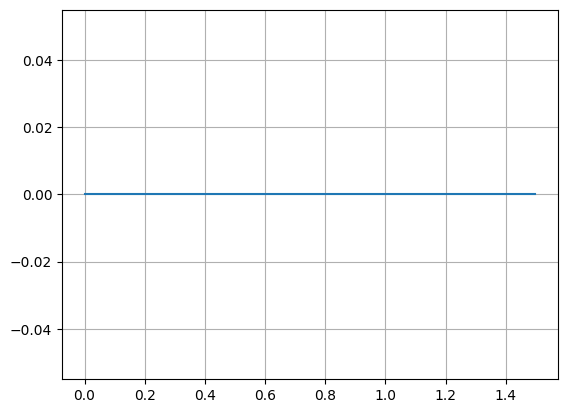

In [17]:
state0 = [0.0, 0.0, 0.0]

t_span = (0,10)
dt = 0.01
t_eval = np.arange(t_span[0], t_span[1], dt)

omega1 = 6.0
omega2 = 6.0

sol = solve_ivp(
    kinematic_model, 
    t_span, 
    state0, 
    t_eval = t_eval, 
    args = (omega1, omega2, r, L), 
    method = 'RK45'
)

x = sol.y[0]
y = sol.y[1]
theta = sol.y[2]
plt.plot(x, y)
plt.grid(True)
plt.show()